#**Step 1 — Business Understanding**

# 📱 Customer Churn Prediction

## 1. Business Understanding

### Problem Statement
Telecom companies lose significant revenue when customers cancel
their subscriptions (churn).
Acquiring a new customer costs 5-7x more than retaining an existing one.

### Goal
Build a machine learning model that predicts whether a customer
will churn based on their account information and usage patterns.

### Why It Matters
- Reduce customer loss and revenue impact
- Enable proactive retention strategies
- Identify high-risk customers before they leave

### Most Important Metric
Recall — because missing a customer who will churn is far more
costly than offering a retention deal to a loyal customer.

### Target Variable
- 0 = Customer stayed ✅
- 1 = Customer churned ❌

#**Step 2 — Imports**

In [27]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Sklearn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Sklearn - Evaluation
from sklearn.metrics import (classification_report,
                             ConfusionMatrixDisplay,
                             roc_auc_score,
                             RocCurveDisplay)

# Sklearn - Interpretation
from sklearn.inspection import permutation_importance

# Model Saving
import joblib
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')



#**Step 3 — Helper Functions**

In [28]:
def classification_metrics(y_true, y_pred, label='',
                           output_dict=False, figsize=(8,4),
                           normalize='true', cmap='Blues',
                           colorbar=False):
    report = classification_report(y_true, y_pred)
    header = "-"*70
    print(header, f" Classification Metrics: {label}", header, sep='\n')
    print(report)
    fig, axes = plt.subplots(ncols=2, figsize=figsize)
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=None, cmap='gist_gray', colorbar=colorbar,
                ax=axes[0])
    axes[0].set_title("Raw Counts")
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred,
                normalize=normalize, cmap=cmap, colorbar=colorbar,
                ax=axes[1])
    axes[1].set_title("Normalized Confusion Matrix")
    fig.tight_layout()
    plt.show()
    if output_dict==True:
        report_dict = classification_report(y_true, y_pred, output_dict=True)
        return report_dict


def evaluate_classification(model, X_train, y_train, X_test, y_test,
                         figsize=(6,4), normalize='true', output_dict=False,
                            cmap_train='Blues', cmap_test="Reds", colorbar=False):
    y_train_pred = model.predict(X_train)
    results_train = classification_metrics(y_train, y_train_pred,
                                     output_dict=True, figsize=figsize,
                                     colorbar=colorbar, cmap=cmap_train,
                                     label='Training Data')
    print()
    y_test_pred = model.predict(X_test)
    results_test = classification_metrics(y_test, y_test_pred,
                                  output_dict=True, figsize=figsize,
                                  colorbar=colorbar, cmap=cmap_test,
                                  label='Test Data')
    if output_dict==True:
        results_dict = {'train': results_train, 'test': results_test}
        return results_dict



#**Step 4 — Load Data**

In [25]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [26]:

df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/Week06/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#**Step 5 — Data Understanding**

In [29]:
# Basic Info
print('='*50)
print('DATASET SHAPE')
print('='*50)
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')

print('\n' + '='*50)
print('COLUMN TYPES')
print('='*50)
print(df.dtypes)

print('\n' + '='*50)
print('BASIC STATISTICS')
print('='*50)
df.describe()

DATASET SHAPE
Rows: 7,043
Columns: 21

COLUMN TYPES
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

BASIC STATISTICS


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [30]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].isnull().sum())

11


#**Step 6 — Target Variable**

TARGET VARIABLE DISTRIBUTION
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn Rate: 26.54%


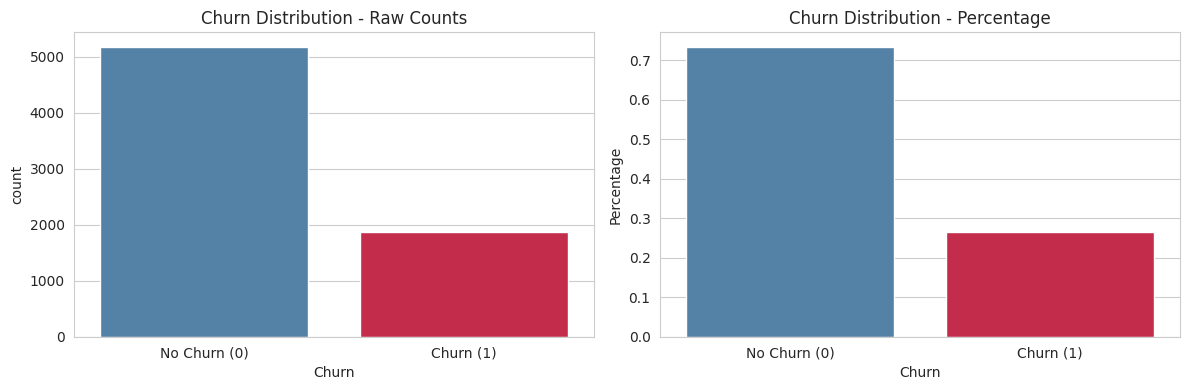

In [31]:
# Convert target to numeric
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('='*50)
print('TARGET VARIABLE DISTRIBUTION')
print('='*50)
print(df['Churn'].value_counts())
print(f'\nChurn Rate: {df["Churn"].mean()*100:.2f}%')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='Churn',palette=['steelblue','crimson'], ax=axes[0])
axes[0].set_title('Churn Distribution - Raw Counts')
axes[0].set_xticklabels(['No Churn (0)', 'Churn (1)'])


default_pct = df['Churn'].value_counts(normalize=True).reset_index()
default_pct.columns = ['Churn', 'Percentage']
sns.barplot(data=default_pct, x='Churn', y='Percentage',palette=['steelblue','crimson'], ax=axes[1])
axes[1].set_title('Churn Distribution - Percentage')
axes[1].set_xticklabels(['No Churn (0)', 'Churn (1)'])

plt.tight_layout()
plt.show()

### Target Variable Analysis

- No Churn (0): 5,174 customers → 73.46%
- Churn (1):    1,869 customers → 26.54%

⚠️ Dataset is imbalanced — 26.54% churn rate

 (Out of every 100 customers of the telecommunications company — 26 customers left the company and 74 were lost)

Primary metric → Recall (detecting churners is our priority)

#**Step 7 — Missing Values & Duplicates**

In [38]:
# Missing Values
print('='*50)
print('MISSING VALUES')
print('='*50)
print(f'Total Missing: {df.isnull().sum().sum()}')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Duplicates
print('\n' + '='*50)
print('DUPLICATES')
print('='*50)
print(f'Total Duplicates: {df.duplicated().sum()}')

if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f'Removed! New shape: {df.shape}')
else:
    print('No duplicates found ✅')

MISSING VALUES
Total Missing: 11
TotalCharges    11
dtype: int64

DUPLICATES
Total Duplicates: 0
No duplicates found ✅


#**Step 8 — EDA: Numerical Features**

Numerical Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


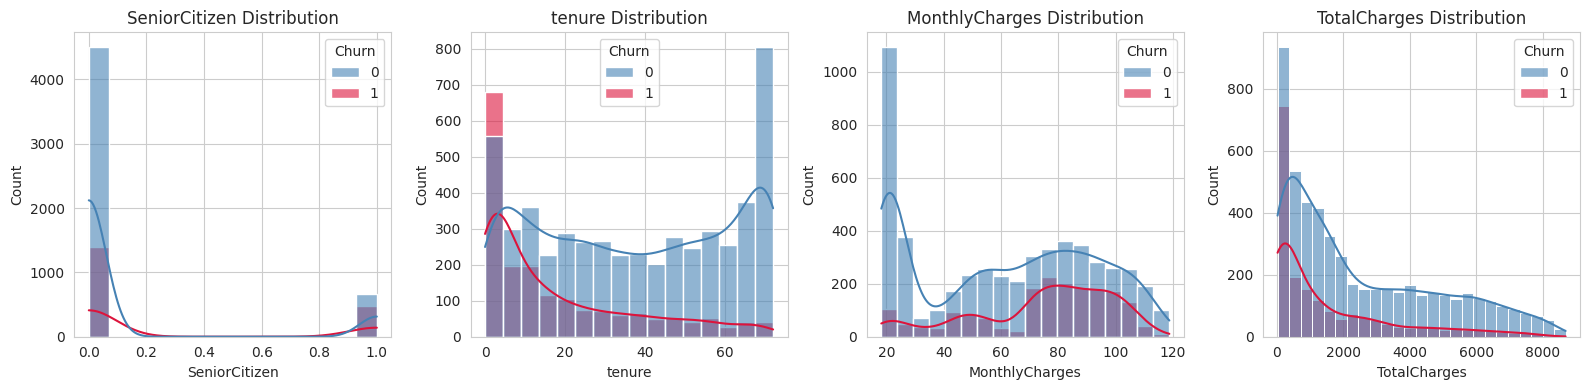

In [39]:
# Numerical columns
num_cols = df.select_dtypes('number').columns.tolist()
num_cols = [col for col in num_cols if col != 'Churn']
print(f'Numerical Features: {num_cols}')

# Distribution plots
fig, axes = plt.subplots(1, len(num_cols), figsize=(16, 4))

for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, hue='Churn',
                 palette=['steelblue','crimson'],
                 kde=True, ax=axes[i], alpha=0.6)
    axes[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

#**Step 9 — EDA: Categorical Features**

Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


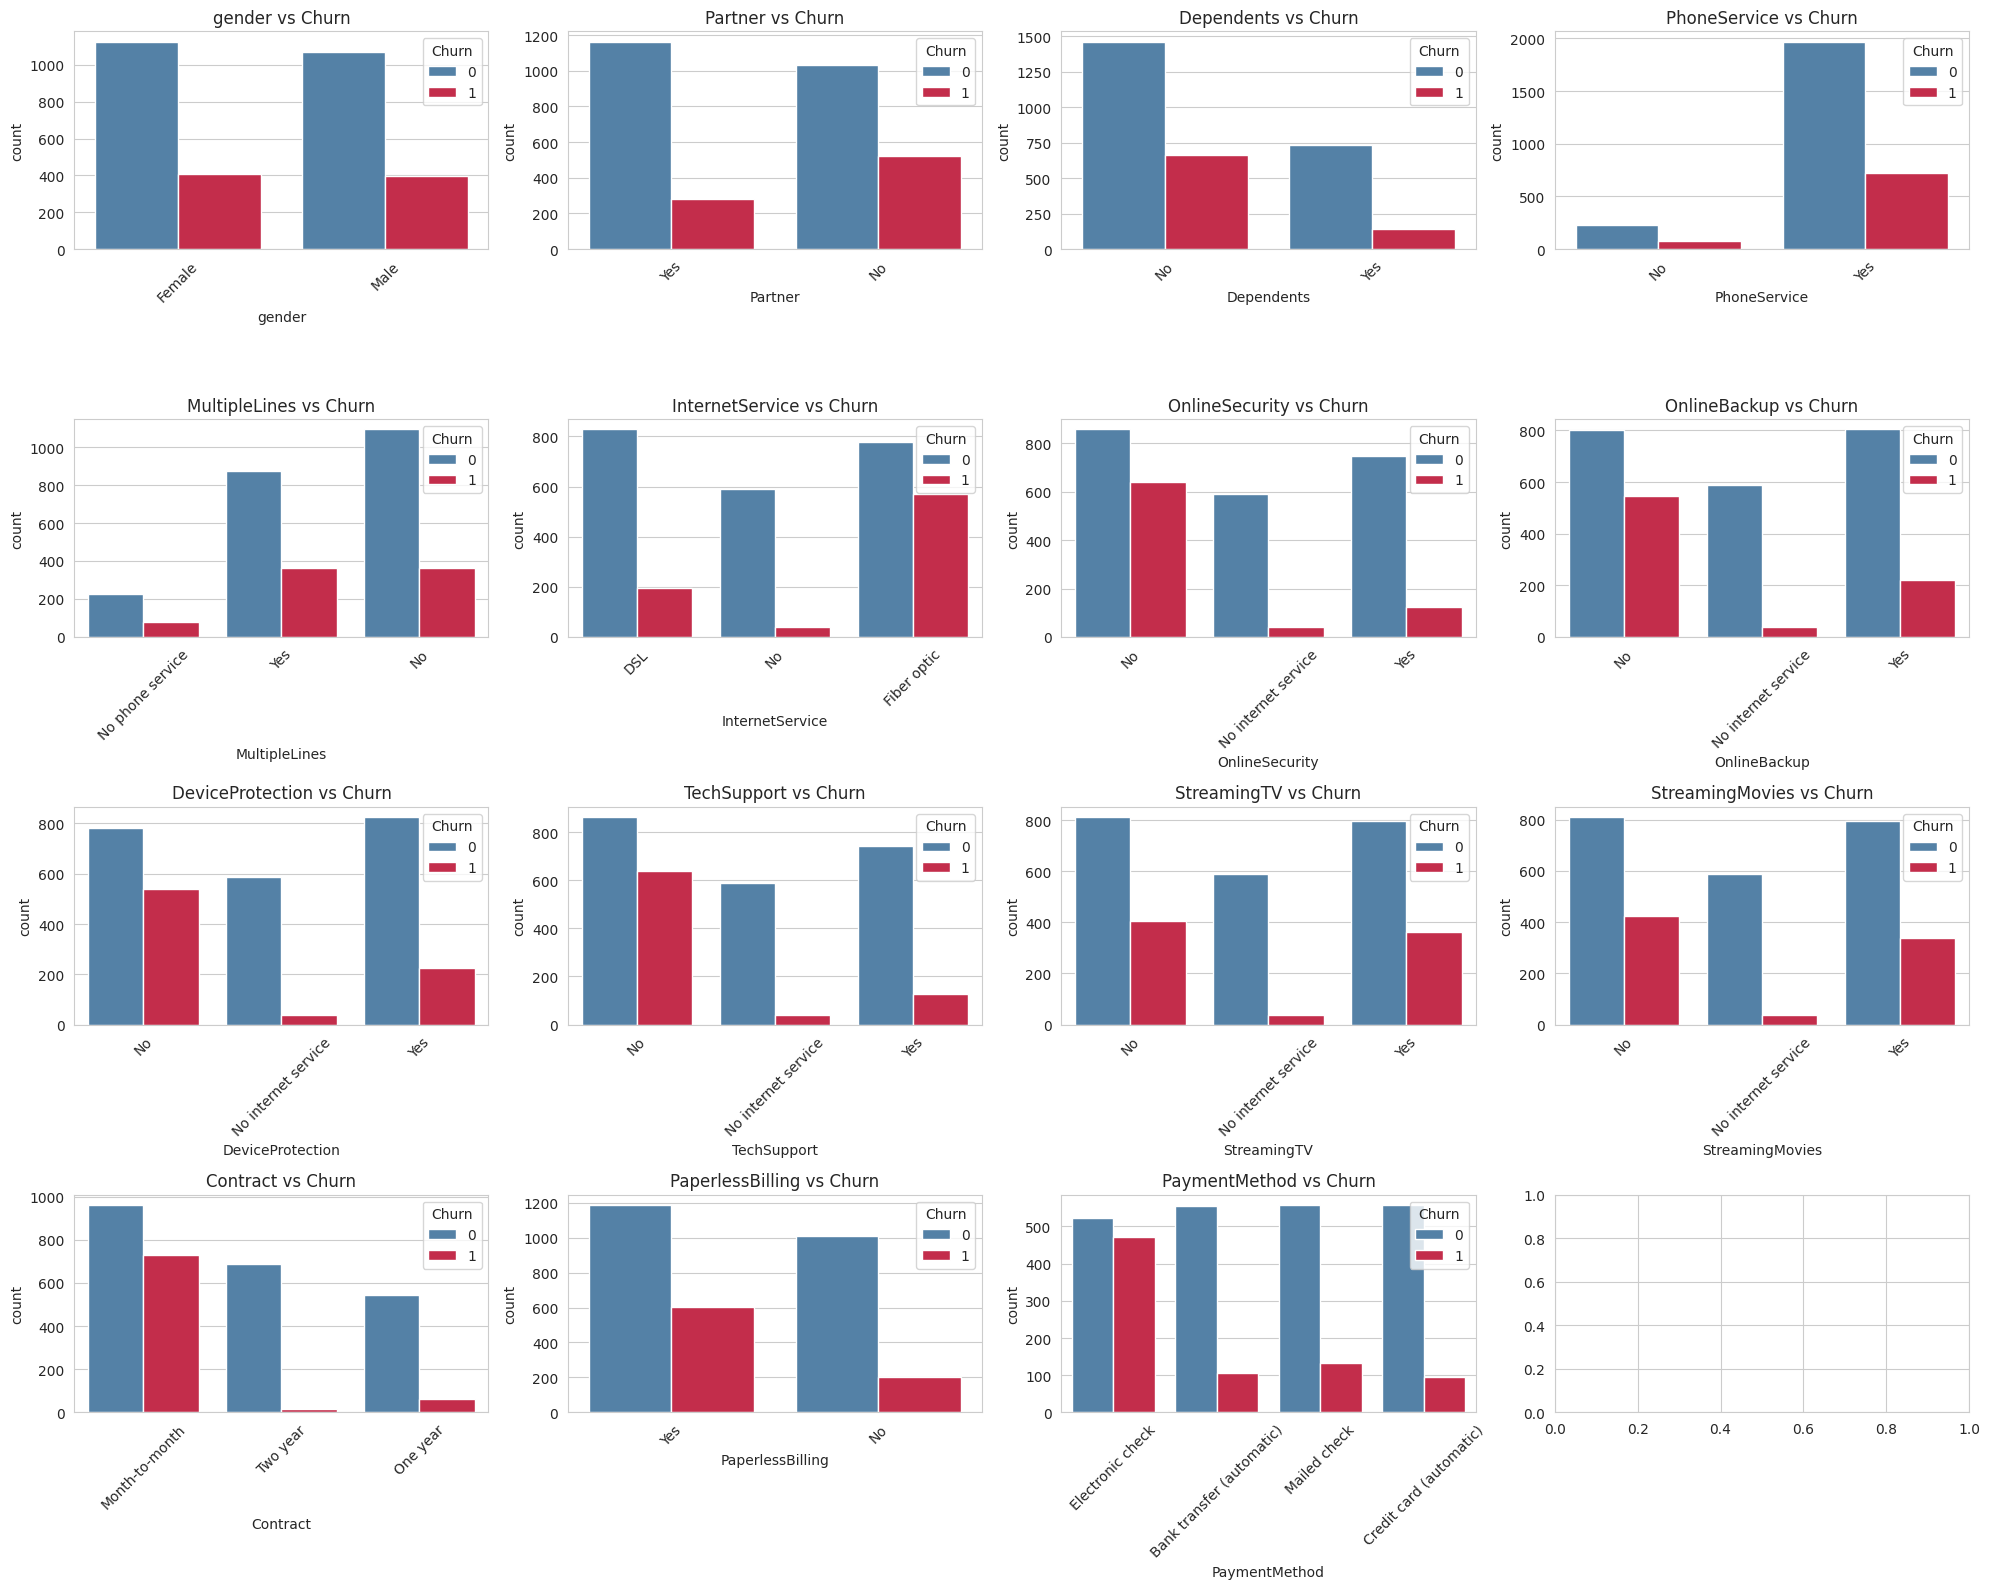

In [40]:
# Categorical columns
cat_cols = df.select_dtypes('object').columns.tolist()
cat_cols = [col for col in cat_cols if col != 'customerID']
print(f'Categorical Features: {cat_cols}')


df_sample = df.sample(3000, random_state=42)

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df_sample, x=col, hue='Churn',
                  palette=['steelblue','crimson'],
                  ax=axes[i])
    axes[i].set_title(f'{col} vs Churn')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 2.3 EDA — Numerical Features Analysis

| Feature        | Observation                                        | Useful? |
|----------------|----------------------------------------------------|---------|
| SeniorCitizen  | Senior customers show slightly higher churn rate   | ⚠️      |
| Tenure         | New customers churn far more than long-term ones   | ✅      |
| MonthlyCharges | Higher charges strongly associated with churn      | ✅      |
| TotalCharges   |Column needs conversion to numeric — not readable   |  ⚠️      |

---

### 2.4 EDA — Categorical Features Analysis

| Feature           | Observation                                              | Useful? |
|-------------------|----------------------------------------------------------|---------|
| gender            | No difference between male and female churn rates        | ❌      |
| Partner           | Customers without a partner churn more                   | ⚠️      |
| Dependents        | Customers without dependents churn more                  | ⚠️      |
| PhoneService      | Minimal difference between groups                        | ❌      |
| MultipleLines     | No clear difference                                      | ❌      |
| InternetService   | Fiber Optic customers churn significantly more           | ✅      |
| OnlineSecurity    | No security = much higher churn                          | ✅      |
| OnlineBackup      | No backup = higher churn                                 | ⚠️      |
| DeviceProtection  | No protection = higher churn                             | ⚠️      |
| TechSupport       | No tech support = significantly higher churn             | ✅      |
| StreamingTV       | Minimal difference                                       | ❌      |
| StreamingMovies   | Minimal difference                                       | ❌      |
| Contract          | Month-to-month contracts have by far the highest churn   | ✅      |
| PaperlessBilling  | Paperless billing customers churn more                   | ⚠️      |
| PaymentMethod     |        Electronic check users show highest churn rate           | ✅      |


---

### Summary

Most impactful features for predicting Churn:

→ Contract type (Month-to-month = highest risk)

→ Internet Service (Fiber Optic = highest risk)

→ Tenure (New customers = highest risk)

→ Monthly Charges (High charges = higher churn)

→ Online Security & Tech Support (absence = higher churn)

Features with no clear impact:

→ gender, PhoneService, StreamingTV, StreamingMovies

→ We will keep ALL features and let the model decide
  what is important during training.

#**Step 10 — Data Preparation**

In [41]:

# Drop customerID - not useful
df = df.drop(columns=['customerID'])

print(f'Final Shape: {df.shape}')
df.head()

Final Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


#**Step 11 — Define X, y + Train Test Split**

In [42]:
# Define X and y
X = df.drop(columns=['Churn'])
y = df['Churn']

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Features: {X.columns.tolist()}')

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

print(f'\nX_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')

X shape: (7043, 19)
y shape: (7043,)
Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

X_train: (5282, 19)
X_test: (1761, 19)


#**Step 12 — Preprocessor**

In [43]:
# Numerical columns
num_cols = X_train.select_dtypes('number').columns.tolist()
print(f'Numerical: {num_cols}')

# Categorical columns
cat_cols = X_train.select_dtypes('object').columns.tolist()
print(f'Categorical: {cat_cols}')

# Numerical Pipeline
num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

# Categorical Pipeline
cat_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)

# Column Transformer
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

print('✅ Preprocessor Ready!')

Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
✅ Preprocessor Ready!


#**Step 13 — Apply SMOTE**

In [44]:
from imblearn.pipeline import make_pipeline as make_smote_pipeline
from imblearn.over_sampling import SMOTE

# Check balance before SMOTE
print('Before SMOTE:')
print(y_train.value_counts())

# SMOTE بيشتغل بعد الـ preprocessor
# بنطبق preprocessor أولاً بعدين SMOTE
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print('\nAfter SMOTE:')
print(pd.Series(y_train_smote).value_counts())
print(f'New Training Shape: {X_train_smote.shape}')

Before SMOTE:
Churn
0    3892
1    1390
Name: count, dtype: int64

After SMOTE:
Churn
1    3892
0    3892
Name: count, dtype: int64
New Training Shape: (7784, 45)


#**Step 14 — Logistic Regression Default**

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.79      0.73      0.76      3892
           1       0.75      0.81      0.78      3892

    accuracy                           0.77      7784
   macro avg       0.77      0.77      0.77      7784
weighted avg       0.77      0.77      0.77      7784



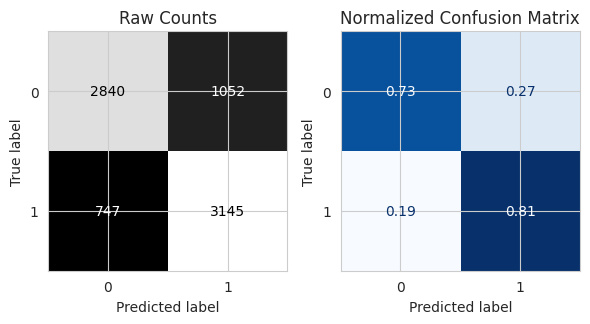


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.74      0.81      1282
           1       0.53      0.81      0.64       479

    accuracy                           0.76      1761
   macro avg       0.72      0.77      0.73      1761
weighted avg       0.81      0.76      0.77      1761



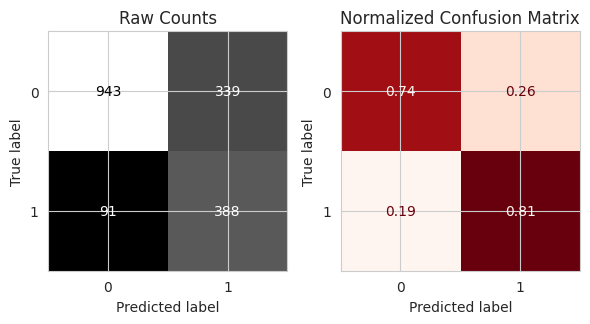

In [45]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_smote, y_train_smote)

evaluate_classification(lr, X_train_smote, y_train_smote,
                           X_test_processed, y_test)

#**Step 15 — Logistic Regression Tuned**

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Params: {'C': 10, 'penalty': 'l1', 'solver': 'saga'}
----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.79      0.73      0.76      3892
           1       0.75      0.81      0.78      3892

    accuracy                           0.77      7784
   macro avg       0.77      0.77      0.77      7784
weighted avg       0.77      0.77      0.77      7784



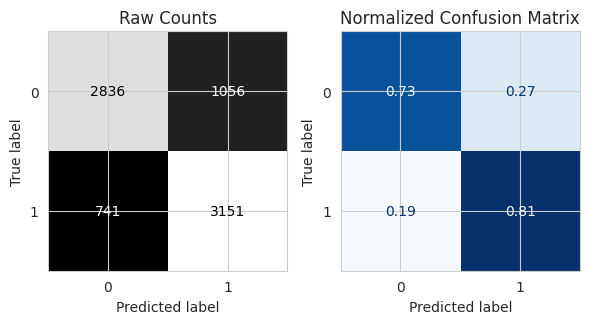


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1282
           1       0.54      0.81      0.65       479

    accuracy                           0.76      1761
   macro avg       0.73      0.78      0.73      1761
weighted avg       0.81      0.76      0.77      1761



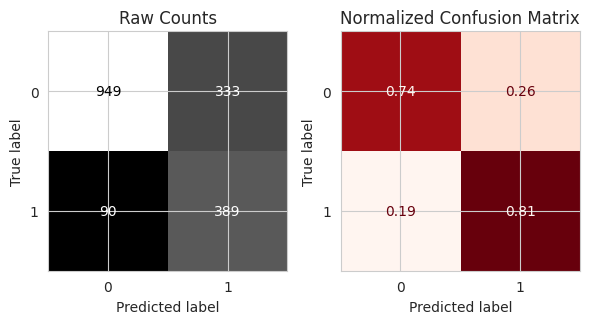

In [46]:
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

gs_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                     lr_params,
                     scoring='recall_macro',
                     cv=3,
                     n_jobs=-1,
                     verbose=1)

gs_lr.fit(X_train_smote, y_train_smote)
print(f'Best Params: {gs_lr.best_params_}')

evaluate_classification(gs_lr.best_estimator_,
                        X_train_smote, y_train_smote,
                        X_test_processed, y_test)

#**Step 16 — Random Forest Default**

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3892
           1       1.00      1.00      1.00      3892

    accuracy                           1.00      7784
   macro avg       1.00      1.00      1.00      7784
weighted avg       1.00      1.00      1.00      7784



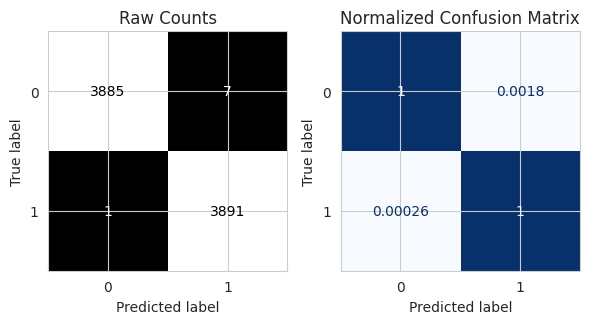


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.87      0.85      1282
           1       0.61      0.55      0.58       479

    accuracy                           0.78      1761
   macro avg       0.72      0.71      0.71      1761
weighted avg       0.77      0.78      0.78      1761



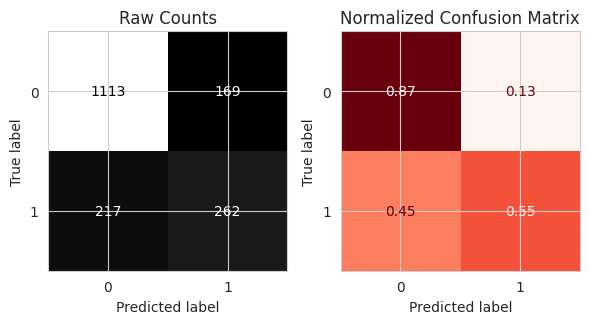

In [90]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_smote, y_train_smote)

evaluate_classification(rf, X_train_smote, y_train_smote,
                           X_test_processed, y_test)

#**Step 17 — Random Forest Tuned**

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params: {'class_weight': None, 'max_depth': 20, 'n_estimators': 200}
----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3892
           1       0.98      1.00      0.99      3892

    accuracy                           0.99      7784
   macro avg       0.99      0.99      0.99      7784
weighted avg       0.99      0.99      0.99      7784



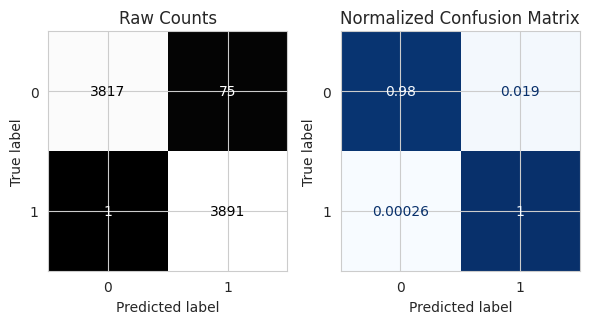


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1282
           1       0.60      0.57      0.59       479

    accuracy                           0.78      1761
   macro avg       0.72      0.72      0.72      1761
weighted avg       0.78      0.78      0.78      1761



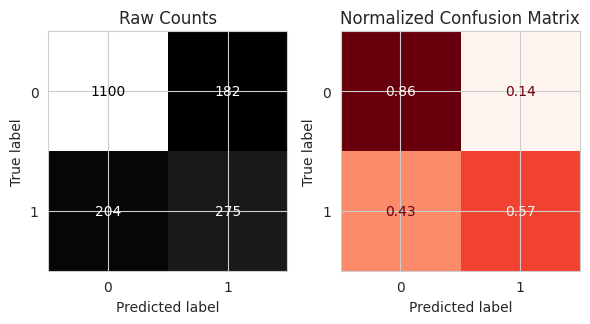

In [91]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'class_weight': ['balanced', None]
}

gs_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                     rf_params,
                     scoring='recall_macro',
                     cv=3,
                     n_jobs=-1,
                     verbose=1)

gs_rf.fit(X_train_smote, y_train_smote)
print(f'Best Params: {gs_rf.best_params_}')

evaluate_classification(gs_rf.best_estimator_,
                        X_train_smote, y_train_smote,
                        X_test_processed, y_test)

#**joblib**

In [55]:
import joblib

joblib.dump(gs_lr.best_estimator_, '/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/churn_best_lr.pkl')
joblib.dump(gs_rf.best_estimator_, '/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/churn_best_rf.pkl')

print('✅ Models saved!')

✅ Models saved!


In [56]:
best_lr = joblib.load('/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/churn_best_lr.pkl')
best_rf = joblib.load('/content/drive/MyDrive/AXSOSACADEMY/02-MachineLearning/churn_best_rf.pkl')

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.79      0.73      0.76      3892
           1       0.75      0.81      0.78      3892

    accuracy                           0.77      7784
   macro avg       0.77      0.77      0.77      7784
weighted avg       0.77      0.77      0.77      7784



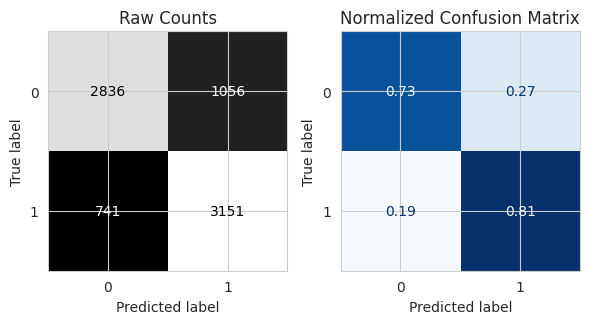


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1282
           1       0.54      0.81      0.65       479

    accuracy                           0.76      1761
   macro avg       0.73      0.78      0.73      1761
weighted avg       0.81      0.76      0.77      1761



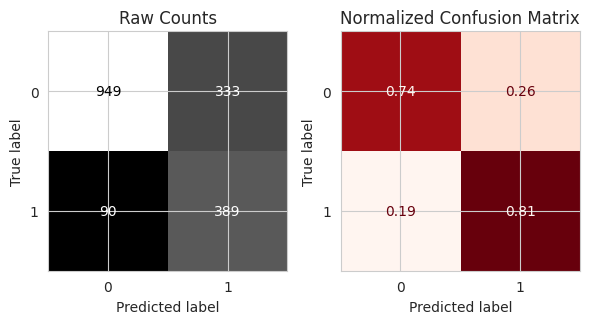

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      3892
           1       0.98      1.00      0.99      3892

    accuracy                           0.99      7784
   macro avg       0.99      0.99      0.99      7784
weighted avg       0.99      0.99      0.99      7784



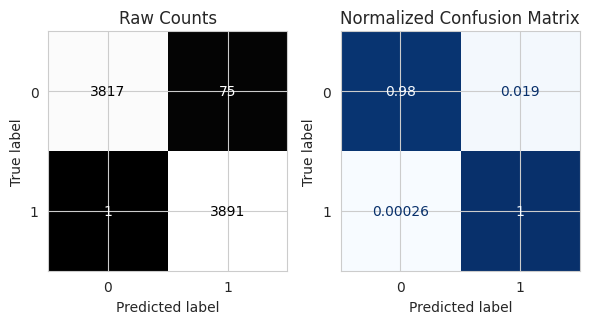


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      1282
           1       0.60      0.57      0.59       479

    accuracy                           0.78      1761
   macro avg       0.72      0.72      0.72      1761
weighted avg       0.78      0.78      0.78      1761



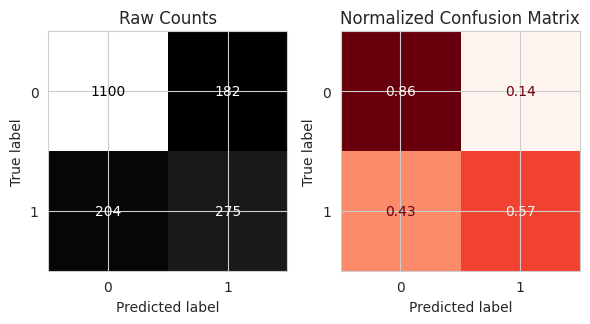

In [57]:
evaluate_classification(best_lr, X_train_smote, y_train_smote, X_test_processed, y_test)
evaluate_classification(best_rf, X_train_smote, y_train_smote, X_test_processed, y_test)


#**Step 18 — ROC Curve Comparison**

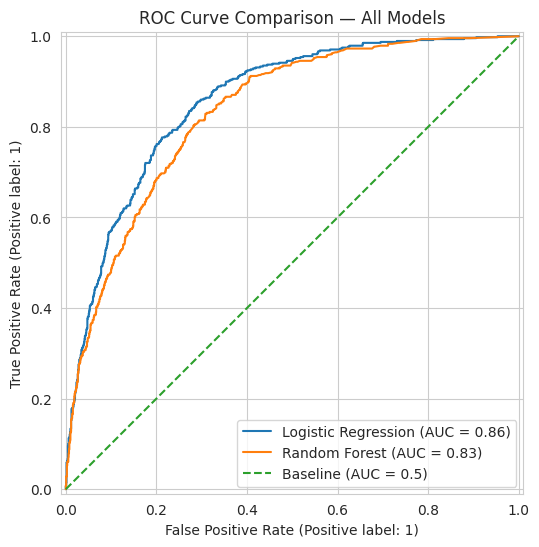

In [49]:
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_estimator(gs_lr.best_estimator_,
                                X_test_processed, y_test,
                                ax=ax, name='Logistic Regression')

RocCurveDisplay.from_estimator(gs_rf.best_estimator_,
                                X_test_processed, y_test,
                                ax=ax, name='Random Forest')

ax.plot([0, 1], [0, 1], ls='--', label='Baseline (AUC = 0.5)')
ax.set_title('ROC Curve Comparison — All Models')
plt.legend()
plt.show()

### Model 1 — Logistic Regression

| Model    | Recall (1) Test | Recall (0) Test | Macro Recall | AUC  |
|----------|----------------|----------------|--------------|------|
| Default  | 0.81           | 0.74           | 0.77         | —    |
| Tuned    | 0.81           | 0.74           | 0.78         | 0.86 |

✅ GridSearch Best Params: C=10, penalty=l1, solver=saga
⚠️ Minimal improvement from tuning — Default model was already well-calibrated with SMOTE

---

### Model 2 — Random Forest

| Model    | Recall (1) Test | Recall (0) Test | Macro Recall | AUC  |
|----------|----------------|----------------|--------------|------|
| Default  | 0.55           | 0.87           | 0.71         | —    |
| Tuned    | 0.57           | 0.86           | 0.72         | 0.83 |

⚠️ Default showed severe Overfitting → Train Recall = 1.00 vs Test = 0.55
✅ GridSearch Best Params: class_weight=None, max_depth=20, n_estimators=200

---

### Final Comparison — All Models

| Model                      | Recall (1) | Recall (0) | Macro Recall | AUC  |
|----------------------------|------------|------------|--------------|------|
| Logistic Regression Default| 0.81       | 0.74       | 0.77         | —    |
| Logistic Regression Tuned  | 0.81       | 0.74       | 0.78         | 0.86 ✅|
| Random Forest Default      | 0.55       | 0.87       | 0.71         | —    |
| Random Forest Tuned        | 0.57       | 0.86       | 0.72         | 0.83 |

---

### ROC Curve Analysis

The ROC Curve compares both tuned models across all thresholds:

- Logistic Regression (AUC = 0.86) → Best overall performance ✅
- Random Forest (AUC = 0.83) → Good but slightly lower
- Baseline (AUC = 0.50) → Random guessing

→ Logistic Regression stays consistently closer to the top-left corner
  meaning it detects more churners with fewer false alarms across all thresholds.

---

### ✅ Recommended Model — Logistic Regression (Tuned)

- Highest Recall for Churn (1) = 0.81 → detects 81% of actual churners
- Highest AUC = 0.86 → best discrimination ability
- No overfitting → Training and Test scores are balanced
- Fast and interpretable → easy to explain to business stakeholders

#**Step 19 — Feature Importance**

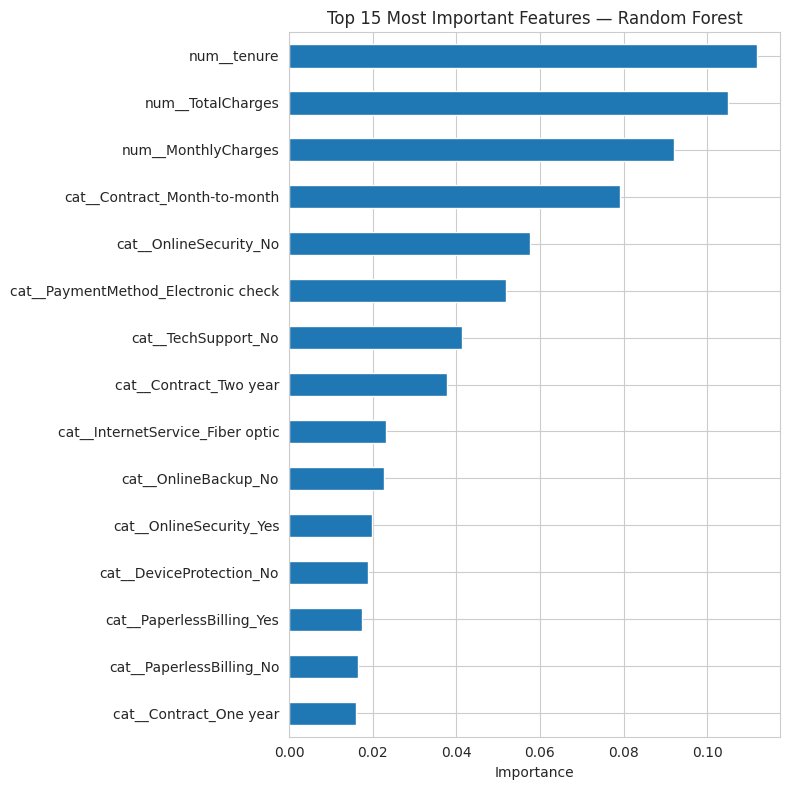

In [94]:
# Feature names بعد الـ preprocessing
feature_names = preprocessor.get_feature_names_out()

# Random Forest Feature Importance
importances = gs_rf.best_estimator_.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=True).tail(15)

feat_imp.plot(kind='barh', figsize=(8, 8))
plt.title('Top 15 Most Important Features — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 📊 Feature Importance Analysis - Random Forest

This visualization represents the **Top 15 Most Important Features** that influenced our Random Forest model's predictions. Understanding these features helps us identify the key drivers of customer churn.

### 📝 Key Insights:

| Feature | Category | Business Impact |
| :--- | :--- | :--- |
| **Tenure** | Customer Loyalty | The strongest predictor; longer relationships reduce churn risk. |
| **Charges** (Monthly/Total) | Financial | High billing amounts are primary drivers for customer departure. |
| **Month-to-Month Contract** | Contract Type | Represents the highest risk group compared to long-term plans. |
| **Online Security & Tech Support** | Service Quality | Customers without these services are significantly more likely to churn. |
| **Fiber Optic Internet** | Infrastructure | Indicates specific service issues or higher costs associated with fiber. |




#**Step 20 — Permutation Importance**

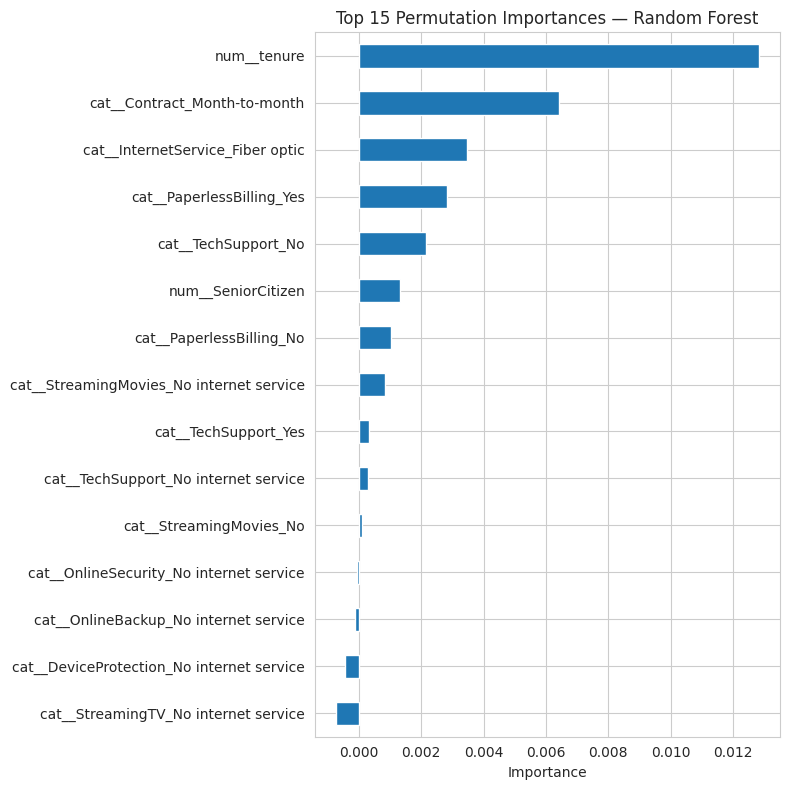

In [95]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(gs_rf.best_estimator_,
                               X_test_processed, y_test,
                               n_repeats=10,
                               random_state=42)

perm_imp = pd.Series(perm.importances_mean,
                     index=feature_names).sort_values(ascending=True).tail(15)

perm_imp.plot(kind='barh', figsize=(8, 8))
plt.title('Top 15 Permutation Importances — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### 🔍 Permutation Importance Analysis

Permutation importance measures how much the model's performance drops when a single feature is randomly shuffled. This provides a more reliable look at feature significance.


| Feature | Importance Score | Insight |
| :--- | :--- | :--- |
| **Tenure** | 0.0128 | The most critical feature; shuffling it causes the largest drop in accuracy. |
| **Month-to-month Contract** | 0.0064 | A primary indicator; the model relies heavily on contract type for its logic. |
| **Fiber Optic Internet** | 0.0035 | Indicates that internet infrastructure is a key differentiator in churn behavior. |
| **Paperless Billing** | 0.0028 | Shows a moderate impact on how the model distinguishes between customers. |
| **Tech Support (No)** | 0.0022 | Confirms that lack of support is a notable factor in the model's decision-making. |

**Summary:** `Tenure` and `Contract Type` are the most robust predictors. Features with scores near 0.000 have minimal impact on the model's predictive power.


#**Step 21 — Logistic Regression Coefficients**

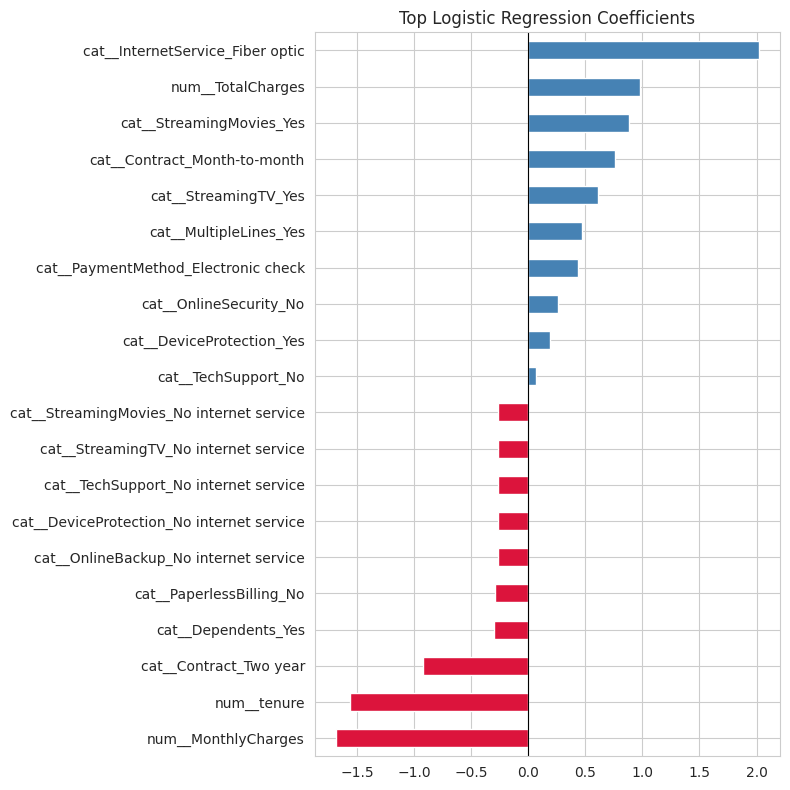

In [96]:
coefficients = gs_lr.best_estimator_.coef_[0]
coef_series = pd.Series(coefficients,
                        index=feature_names).sort_values(ascending=True)

# Top 15 positive and negative
top_coef = pd.concat([coef_series.head(10), coef_series.tail(10)])

top_coef.plot(kind='barh', figsize=(8, 8),
              color=top_coef.map(lambda x: 'crimson' if x < 0 else 'steelblue'))
plt.title('Top Logistic Regression Coefficients')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# 📈 Logistic Regression Coefficients Analysis

The coefficients reveal the **strength** and **direction** of the relationship between customer features and the likelihood of **Churn**.

### 📊 Model Insights Table


| Feature Group | Influence Type | Business Interpretation |
| :--- | :--- | :--- |
| **Fiber Optic & Electronic Check** | 🔵 **Positive (Risk)** | These are the primary **Churn Drivers**. Customers using these services are at higher risk of leaving. |
| **Total Charges** | 🔵 **Positive (Risk)** | High overall spending correlates with a higher probability of churning. |
| **Tenure (Loyalty)** | 🔴 **Negative (Retention)** | **Strongest Stabilizer:** The longer a customer stays, the less likely they are to churn. |
| **Two-year Contract** | 🔴 **Negative (Retention)** | Long-term commitments significantly increase customer retention. |
| **Monthly Charges** | 🔴 **Negative (Retention)** | Surprisingly, higher monthly bills in this model context don't necessarily drive churn, often linked to high-value loyal customers. |
| **No Internet Service** | 🔴 **Negative (Retention)** | Customers with basic or no internet services show higher stability. |

---

### 💡 Strategic Summary:
*   **Risk Zone (Blue):** We need to investigate why **Fiber Optic** users are leaving. It could be due to service quality or high competition in that segment.
*   **Safety Zone (Red):** Our best defense against churn is **Tenure** and **Long-term Contracts**. Encouraging customers to move from month-to-month to two-year contracts is a high-priority strategy.


## 🎯 Integrated Model Analysis Conclusion

By synthesizing insights from **Feature Importance**, **Permutation Importance**, and **Logistic Coefficients**, we have developed a high-confidence profile of customer behavior:


| Dimension | Key Finding | Strategic Implication |
| :--- | :--- | :--- |
| **🏆 Primary Driver** | **Tenure & 2-Year Contract** | These are the strongest **Retention Shields**. Long-term commitment is the most effective way to prevent churn. |
| **⚠️ High-Risk Segment** | **Fiber Optic & Electronic Check** | These features are consistently linked to **High Churn Risk**, indicating potential service issues or billing friction. |
| **💰 Financial Impact** | **Total Charges vs. Monthly** | While high **Total Charges** drive churn up, established customers with high **Monthly Charges** tend to be more stable. |
| **🛡️ Stability Factors** | **No Internet Service** | Customers with basic service needs show the highest loyalty and lowest tendency to leave. |

---

### 🏁 Final Verdict & Action Plan:
1.  **Retention Strategy:** Focus on **converting Month-to-Month contracts** into long-term plans through targeted incentives.
2.  **Service Improvement:** Conduct a deep dive into **Fiber Optic service quality** and customer feedback to address the high churn rate in this segment.
3.  **Billing Optimization:** Encourage customers using **Electronic Checks** to switch to more automated or stable payment methods to reduce friction.
